# Projet OAA 2025/2026 Partie 1 : Méthodes primales-duales de base

Implémentation et expériences pour les **questions 1 à 3** du projet.

On considère le programme linéaire sous forme classique
$$\min_{w\in\mathbb{R}^d} c^Tw \quad \text{s.c.} \quad Aw=b,\ w\geq 0,$$
et sa formulation primale-duale
$$\min_{w\geq 0}\max_{z\in\mathbb{R}^r} L(w,z) = c^Tw - z^T(Aw-b). \tag{2}$$

Le problème jouet $\min_{w\geq 0}\max_{z}\ (w-3)z$ correspond à $c=0$, $A=-1$, $b=-3$
(on vérifie : $c^Tw - z(Aw-b) = -z(-w+3) = (w-3)z$). Son point-selle est $(w^\star,z^\star)=(3,0)$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Probleme jouet  min_{w>=0} max_z (w-3)z  sous la forme (1)-(2)
c = np.array([0.0])
A = np.array([[-1.0]])
b = np.array([-3.0])
w0 = np.array([2.0])
z0 = np.array([2.0])
wstar, zstar = 3.0, 0.0

def proj(v):
    """Projection sur l'orthant positif."""
    return np.maximum(v, 0.0)

## Question 1: Descente/montée de gradient (GDA)

Itération (3) du sujet, avec mise à jour **simultanée** (les deux gradients sont évalués en $(w_k, z_k)$) :
$$w_{k+1} = \mathrm{proj}_{\geq 0}\big[w_k - \alpha_k(c - A^Tz_k)\big], \qquad
z_{k+1} = z_k - \beta_k(Aw_k - b).$$

Les pas $\alpha_k,\beta_k$ sont passés comme fonctions de $k$, ce qui permettra de traiter la variante de la question 2 avec le même code.

In [3]:
def gda(c, A, b, w0, z0, alpha, beta, n_iter):
    """Descente/montee de gradient simultanee pour le probleme (2).

    alpha, beta : fonctions k -> pas (mettre lambda k: 0.2 pour un pas constant).
    Retourne la trajectoire, tableau de taille (n_iter+1, d+r)."""
    w, z = w0.copy(), z0.copy()
    traj = [np.concatenate([w, z])]
    for k in range(n_iter):
        w_new = proj(w - alpha(k) * (c - A.T @ z))
        z_new = z - beta(k) * (A @ w - b)   # ancien w : mise a jour simultanee
        w, z = w_new, z_new
        traj.append(np.concatenate([w, z]))
    return np.array(traj)

n_iter = 100
T_gda = gda(c, A, b, w0, z0, lambda k: 0.2, lambda k: 0.2, n_iter)
print("Dernier itere (w, z) :", T_gda[-1])
print("Distance au point-selle :", np.linalg.norm(T_gda[-1] - [wstar, zstar]))

Dernier itere (w, z) : [0.         3.85283581]
Distance au point-selle : 4.883067048809054


**Observation.** Partis à distance $\approx 2{,}24$ du point-selle, on en finit à distance $\approx 4{,}9$ : la méthode **diverge en spiralant** autour de $(3,0)$. C'est le comportement attendu de GDA sur un problème min-max *bilinéaire* : hors projection, la dynamique linéaire a pour matrice $\begin{pmatrix}1 & -\alpha\\ \beta & 1\end{pmatrix}$, de valeurs propres $1\pm i\sqrt{\alpha\beta}$, de module $\sqrt{1{,}04} > 1$. Chaque itération tourne *et* amplifie.

## Question 2: Variante à pas alternés

$$\alpha_{2k} = -\beta_{2k} = -\alpha_{2k+1} = \beta_{2k+1} = 0{,}2$$

Itérations paires : descente en $w$, **descente** en $z$ (mauvais sens !). Itérations impaires : **montée** en $w$ (mauvais sens !), montée en $z$.

In [4]:
alpha_alt = lambda k: 0.2 if k % 2 == 0 else -0.2
beta_alt  = lambda k: -0.2 if k % 2 == 0 else 0.2

T_alt = gda(c, A, b, w0, z0, alpha_alt, beta_alt, n_iter)
print("Dernier itere (w, z) :", T_alt[-1])
print("Distance au point-selle :", np.linalg.norm(T_alt[-1] - [wstar, zstar]))

# Explication : composition de deux iterations successives (hors projection)
M1 = np.array([[1, -0.2], [-0.2, 1.0]])   # pas pair  : descente/descente
M2 = np.array([[1,  0.2], [ 0.2, 1.0]])   # pas impair: montee/montee
print("\nM2 @ M1 =\n", M2 @ M1)   # = 0.96 * Identite !

Dernier itere (w, z) : [2.87011421 0.25977159]
Distance au point-selle : 0.2904334636267803

M2 @ M1 =
 [[0.96 0.  ]
 [0.   0.96]]


**Observation.** La méthode **converge linéairement** vers $(3,0)$, alors que chaque itération prise isolément met à jour l'une des deux variables dans la *mauvaise* direction — c'est ce qui rend cette proposition (récente dans la littérature) surprenante. L'explication : la composition de deux itérations successives vaut exactement $(1-\alpha^2)I = 0{,}96\,I$, une contraction pure. Les directions instables des deux demi-pas se compensent, et le taux observé est bien $0{,}96$ toutes les deux itérations : $2{,}24\times 0{,}96^{50}\approx 0{,}29$.

## Question 3: Méthode primale-duale de gradient hybride (PDHG)

Itération (4) du sujet : seule la mise à jour de $z$ change, le gradient étant évalué au point **extrapolé** $2w_{k+1}-w_k$ :
$$w_{k+1} = \mathrm{proj}_{\geq 0}\big[w_k - \alpha_k(c - A^Tz_k)\big], \qquad
z_{k+1} = z_k - \beta_k\big(A(2w_{k+1}-w_k) - b\big).$$

In [5]:
def pdhg(c, A, b, w0, z0, alpha, beta, n_iter):
    """Primal-Dual Hybrid Gradient (Chambolle-Pock) pour le probleme (2)."""
    w, z = w0.copy(), z0.copy()
    traj = [np.concatenate([w, z])]
    for k in range(n_iter):
        w_new = proj(w - alpha * (c - A.T @ z))
        z_new = z - beta * (A @ (2 * w_new - w) - b)   # point extrapole
        w, z = w_new, z_new
        traj.append(np.concatenate([w, z]))
    return np.array(traj)

T_pdhg = pdhg(c, A, b, w0, z0, 0.2, 0.2, n_iter)
print("Dernier itere (w, z) :", T_pdhg[-1])
print("Distance au point-selle :", np.linalg.norm(T_pdhg[-1] - [wstar, zstar]))

Dernier itere (w, z) : [ 2.68362366 -0.10519927]
Distance au point-selle : 0.3334079729393856


## Comparaison des trois méthodes

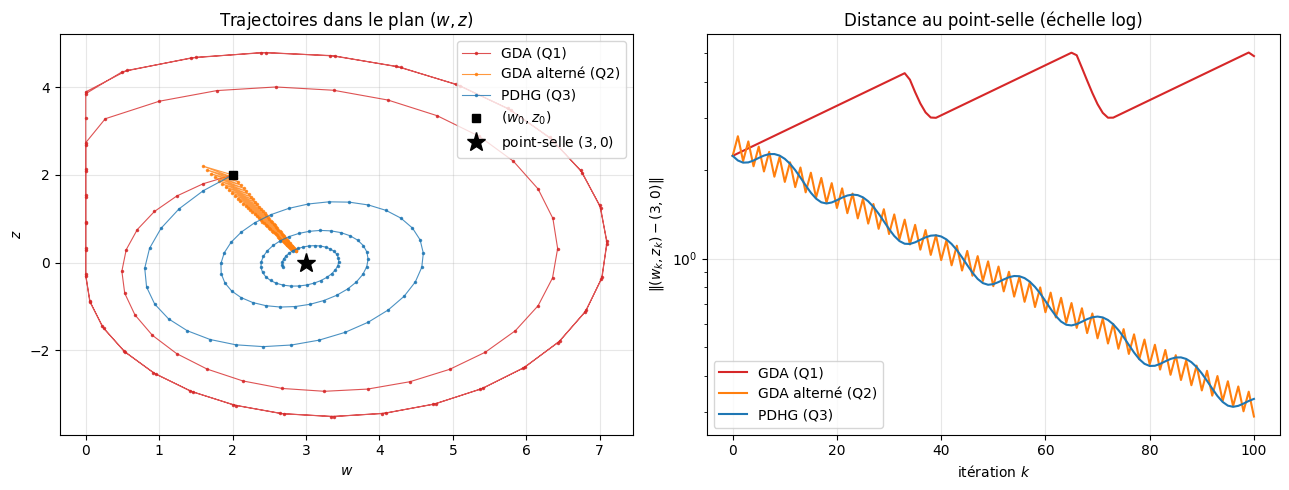

In [6]:
dist = lambda T: np.sqrt((T[:, 0] - wstar)**2 + (T[:, 1] - zstar)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for T, lab, col in [(T_gda,  "GDA (Q1)",          "tab:red"),
                    (T_alt,  "GDA alterné (Q2)",  "tab:orange"),
                    (T_pdhg, "PDHG (Q3)",         "tab:blue")]:
    axes[0].plot(T[:, 0], T[:, 1], ".-", lw=0.8, ms=3, color=col, label=lab, alpha=0.8)
    axes[1].semilogy(dist(T), color=col, label=lab)

axes[0].plot(w0, z0, "ks", label="$(w_0,z_0)$")
axes[0].plot(wstar, zstar, "k*", ms=14, label="point-selle $(3,0)$")
axes[0].set_xlabel("$w$"); axes[0].set_ylabel("$z$")
axes[0].set_title("Trajectoires dans le plan $(w,z)$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("itération $k$")
axes[1].set_ylabel(r"$\|(w_k,z_k)-(3,0)\|$")
axes[1].set_title("Distance au point-selle (échelle log)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures_q1q3.png", dpi=150)
plt.show()

**Bilan.**
GDA simultanée diverge (rayon spectral $\sqrt{1+\alpha\beta}\approx 1{,}02$) ; les dents de scie de sa courbe rouge viennent de la projection qui bloque les itérés sur le bord $w=0$. La variante alternée et PDHG convergent linéairement au même taux sur deux itérations ($0{,}96$ par double pas pour l'une, $\sqrt{0{,}96}\approx 0{,}98$ par pas pour l'autre), mais avec des trajectoires très différentes : zigzag rectiligne pour la variante alternée, spirale rentrante pour PDHG. PDHG bénéficie en outre d'une théorie de convergence générale (condition $\alpha\beta\|A\|^2\leq 1$, largement vérifiée ici : $0{,}04$), ce qui en fait la brique de choix pour la suite du projet (transport optimal, questions 4-6).